In [2]:
import pandas as pd
import numpy as np

In [3]:
#Import CSV-FILE
df=pd.read_csv("mobile_price.csv",encoding='latin1')

In [4]:
# Perform the following:
# Inspect dataset shape, columns, data types, and missing values
df.shape

(161, 14)

In [5]:
df.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [6]:
df.tail()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
156,1206,3551,4638,178.0,5.46,538,4,1.875,128.0,6.0,12.0,16.0,4080,8.4
157,1296,3211,8016,170.0,5.50,534,4,1.975,128.0,6.0,20.0,8.0,3400,7.9
158,856,3260,8809,150.0,5.50,401,8,2.200,64.0,4.0,20.0,20.0,3000,6.8
159,1296,3211,8946,170.0,5.50,534,4,1.975,128.0,6.0,20.0,8.0,3400,7.9
160,1131,2536,9807,202.0,6.00,367,8,1.500,16.0,3.0,21.5,16.0,2700,8.4


In [7]:
df.columns

Index(['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness'],
      dtype='str')

In [8]:
df.dtypes

Product_id        int64
Price             int64
Sale              int64
weight          float64
resoloution     float64
ppi               int64
cpu core          int64
cpu freq        float64
internal mem    float64
ram             float64
RearCam         float64
Front_Cam       float64
battery           int64
thickness       float64
dtype: object

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [10]:
#missing values
print(df.isnull().sum()) # prints missing values

Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64


In [11]:
#duplicate values
print(df.duplicated().sum())

0


In [12]:
# Generate statistical summaries for numerical features
num_cols = df.select_dtypes(include=['number'])
Summary= num_cols.agg(['mean', 'median', 'min', 'max', 'std'])
print(Summary)

         Product_id        Price         Sale      weight  resoloution  \
mean     675.559006  2215.596273   621.465839  170.426087     5.209938   
median   774.000000  2258.000000   106.000000  153.000000     5.150000   
min       10.000000   614.000000    10.000000   66.000000     1.400000   
max     1339.000000  4361.000000  9807.000000  753.000000    12.200000   
std      410.851583   768.187171  1546.618517   92.888612     1.509953   

               ppi  cpu core  cpu freq  internal mem       ram    RearCam  \
mean    335.055901  4.857143  1.502832     24.501714  2.204994  10.378261   
median  294.000000  4.000000  1.400000     16.000000  2.000000  12.000000   
min     121.000000  0.000000  0.000000      0.000000  0.000000   0.000000   
max     806.000000  8.000000  2.700000    128.000000  6.000000  23.000000   
std     134.826659  2.444016  0.599783     28.804773  1.609831   6.181585   

        Front_Cam      battery  thickness  
mean     4.503106  2842.111801   8.921739  
medi

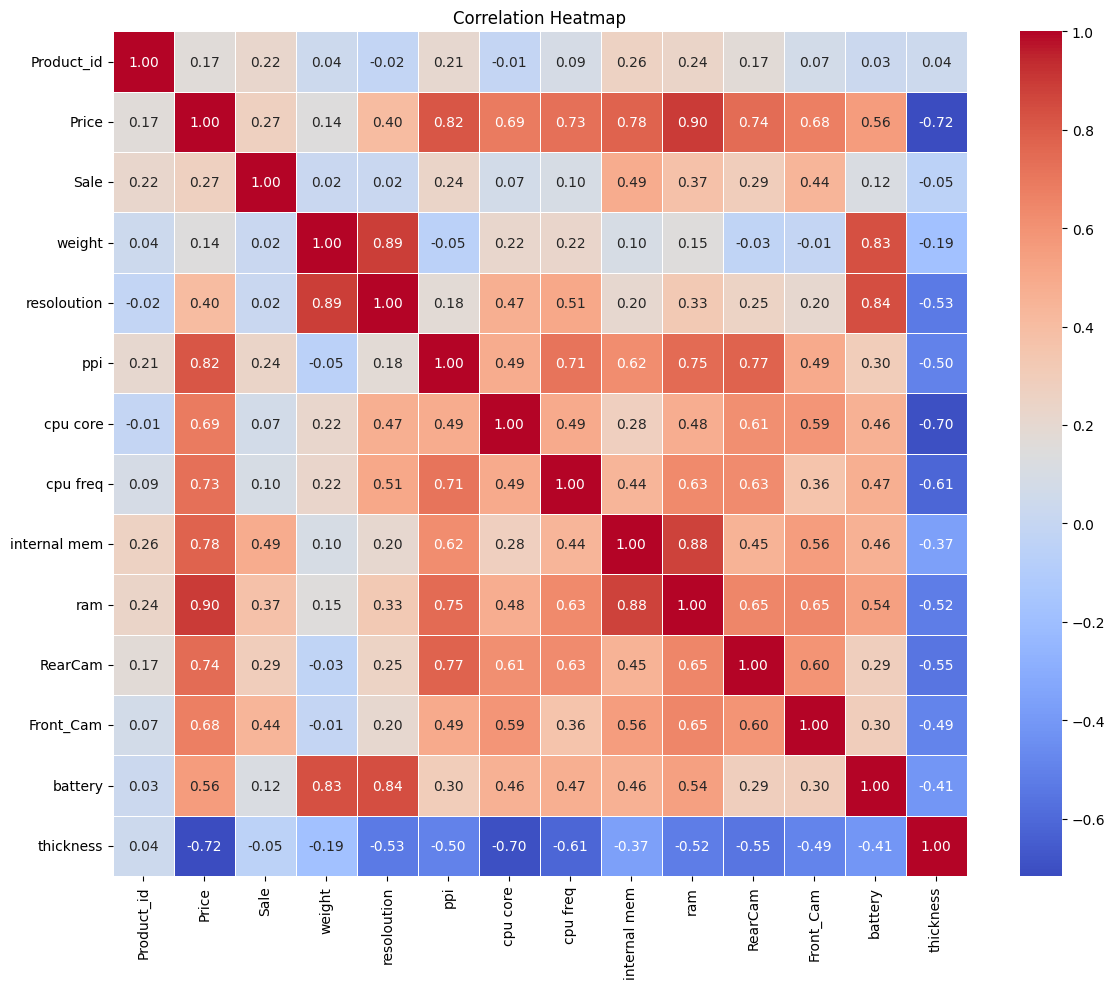

In [13]:
# Numerical columns only
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = num_cols.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [14]:
# Identify the top 4 features most correlated with Price
top_4_features = corr_matrix['Price'].sort_values(ascending=False).head(5)
print(top_4_features)

Price           1.000000
ram             0.896915
ppi             0.817614
internal mem    0.776738
RearCam         0.739538
Name: Price, dtype: float64


Those 4 features are ram , ppi, internal mem, RearCam

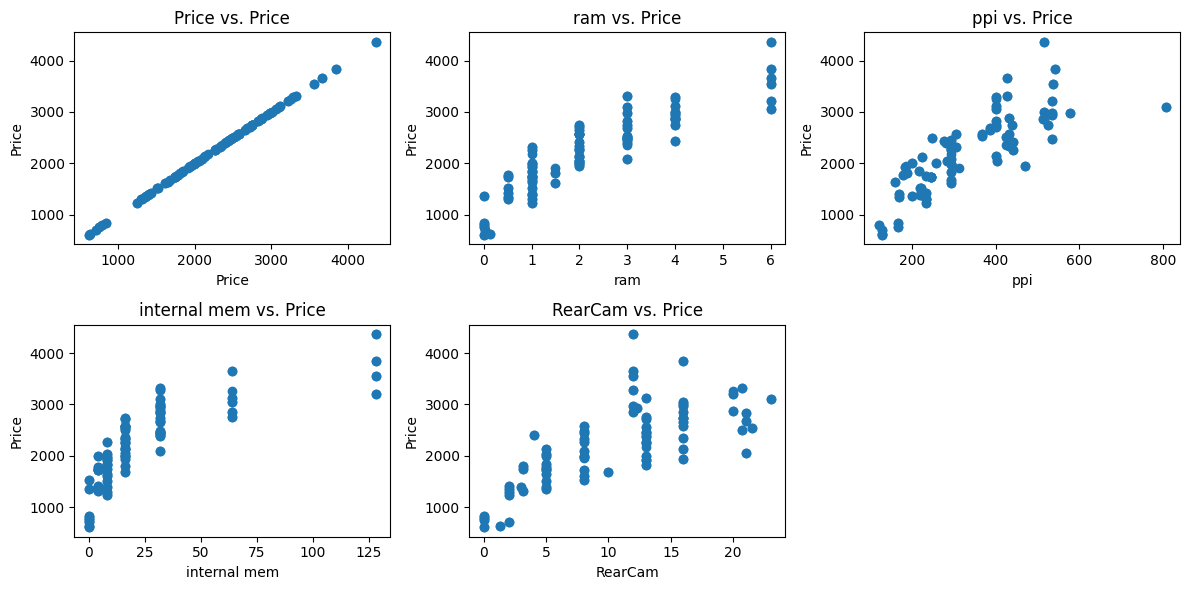

In [15]:
# Plot scatter plots for these features against Price and analyze the relationships
plt.figure(figsize=(12, 6))
for i, feature in enumerate(top_4_features.index, 1):
    plt.subplot(2, 3, i)
    plt.scatter(df[feature], df['Price'])
    plt.title(feature + ' vs. Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [16]:
# Prepare the Data:
# Feature Selection: Select the features and the target variable for your analysis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [17]:
#feature Selection we need to predict the price so we take this as y
from sklearn.feature_selection import SelectKBest, f_regression
X = df.drop(columns=['Price', 'Product_id'])
y = df['Price']
selector = SelectKBest(score_func=f_regression, k=6)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("Best Features:", selected_features.tolist())

Best Features: ['ppi', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'thickness']


In [18]:
#Split the Dataset: Divide the dataset into training and testing sets.
#Use 80% of the data for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X_selected,y, test_size=0.2, random_state=42)

In [19]:
#Total data 161 splited into 80% -128 and 20% -33
print("X_train",X_train.shape)
print("X_test",X_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

X_train (128, 6)
X_test (33, 6)
y_train (128,)
y_test (33,)


In [20]:
# Build and Train the Model:
#Create a Linear Regression Model:
# Build a linear regression model using the training data.

model = LinearRegression()

In [21]:
# Train the Model: Fit the model to the training data.
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 1.09,103.65, 3.4 ,180.58, 10.85,-93.36]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1937
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[1579.44, 254.36, 45.75, 21.32, 6.72, 3.89]"


In [22]:
#Evaluate the Model:
#Predict: Use the model to make predictions on the test set.

y_pred = model.predict(X_test)

In [23]:
y_pred

array([ 914.7301613 , 1930.87776615, 2796.07372631, 1566.76197457,
       1616.69475159, 1972.18751759,  914.7301613 , 1534.86473182,
       2423.83517772, 2796.07372631, 1451.91896954, 1657.22914787,
       1832.2543121 , 2849.76729278, 2297.04997019, 2277.64729713,
       2361.78581726, 3350.81637705, 1559.72143608, 2277.64729713,
       2240.43973256, 1832.2543121 , 2001.79240921, 2498.51922849,
       3026.08411222, 3656.48955129, 2303.11920453, 3387.01502167,
       2739.08367648, 2386.98323617, 2927.58926385, 2593.17321802,
       2541.46252005])

In [24]:
#Metrics Calculation: Evaluate the model’s performance using the following metrics:
#Slope (Coefficient) and Intercept: Print the slope (coefficient) and intercept of the regression line.

print("Model Intercept",model.intercept_)
print("Model Coeffecient",model.coef_)

Model Intercept 1937.2586386978116
Model Coeffecient [  1.08618817 103.64880325   3.39789147 180.57553731  10.8477479
 -93.35506346]


In [25]:
# R² Score:
r2=r2_score(y_test,y_pred)
print("R2 score",r2)

R2 score 0.9071572480014903


In [26]:
# Model Performance Metrics: Calculate and report the following metrics:
mae = mean_absolute_error(y_test,y_pred)
print("mean absolute error",mae)

mean absolute error 182.49729524537184


In [27]:
# Mean Squared Error (MSE):
# What is the average of the squared differences between predicted and actual values?
mse=mean_squared_error(y_test,y_pred)
print("MeanSquared Error",mse)

MeanSquared Error 52631.5376510999


In [28]:
rmse=np.sqrt(mse)
print("Root mean squared error",rmse)

Root mean squared error 229.41564386741348


In [29]:
Residual = y_test - y_pred
print("Residual Errors", Residual)

Residual Errors 105    -81.730161
108   -254.877766
142   -288.073726
55     210.238025
94    -105.694752
29     -22.187518
101    -81.730161
51    -187.864732
100    -80.835178
143   -288.073726
19    -213.918970
84     -11.229148
15    -220.254312
66    -103.767293
24    -355.049970
30     -19.647297
128    129.214183
148   -295.816377
98     -37.721436
16     -19.647297
75      35.560267
18    -220.254312
12     172.207591
9       81.480772
31     -49.084112
152    704.510449
97     258.880795
56     270.984978
132   -273.083676
104    357.016764
137    188.410736
78     120.826782
60     282.537480
Name: Price, dtype: float64


**Concluded the Analysis:
Model Evaluation:**
The Linear Regression model achieved an R² score of **90.7%**, with a MAE of **182.49** and RMSE of **229.41**, indicating excellent predictive performance. The results show that the model accurately predicts mobile phone prices.

# 1) What insights did you gain from the correlation analysis and scatter plots?
* Features such as RAM, internal memory, battery capacity, PPI (pixels per inch), and CPU frequency showed a strong positive correlation with mobile phone prices.

# 2) How do the selected features contribute to the prediction of mobile prices?
* Using Select K best Selected 6 columns that contribute to the prediction of mobile prices

*  ['ppi', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'thickness'] these are the non negotiable features for prediction of price since these are much correlated with price.

# 3) What do the slope (coefficient) and intercept reveal about the relationship between the features and the target variable?
* Linear Regression model produced 1937.26 and coefficients for the relationship between target variable

* RAM (180.58),CPU frequency (103.65),Rear camera quality, internal memory, and PPI Positively towards price prediction

* But thickness (-93.36) showed negative relationship indicates if thickness decrease price Increase.

# 4) How well does the model perform based on the evaluation metrics? Are there any discrepancies between the predicted and actual values?

* The Linear Regression model achieved an R² score of 90.7%, a Mean Absolute Error (MAE) of 182.49, and a Root Mean Squared Error (RMSE) of 229.41.

* However model has slight discrepancies with predicted and actual values.

# 5) What might be some potential improvements or additional steps you could take to enhance the model’s performance?

* Using Additional Features for the model so that it can perform with more accuracy and predicts values with enhanced performance. The more the features selected the more the model becomes accurate.